### Assignment-2
#### Classify the email using the binary classification method. Email Spam detection has two states:

a) Normal State Not Spam                                                                    
b) Abnormal State Spam. Use K-Nearest Neighbors
and Support Vector Machine for classification. Analyze their performance.
Dataset link: The emails.csv dataset on the Kaggle
https://www.kaggle.com/datasets/balaka18/email-spam-classification-dataset-csv

In [1]:
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

In [2]:
df = pd.read_csv("./emails.csv")

In [3]:
df.head()

,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [5]:
#Drop any row with null values
df.dropna(how='any',inplace=True)
df.isnull().sum()

Email No.     0
the           0
to            0
ect           0
and           0
             ..
military      0
allowing      0
ff            0
dry           0
Prediction    0
Length: 3002, dtype: int64

In [6]:
# Drop unnecessary columns
df.drop('Email No.', inplace=True, axis=1)

## K-Nearest Neighbours Classifier

In [29]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
X = df.drop('Prediction', axis=1)
y = df['Prediction']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20,random_state=42)

In [43]:
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
y_pred_knn

array([0, 0, 1, ..., 0, 1, 0], dtype=int64)

Accuracy:  0.8850
Precision: 0.7846
Recall:    0.8243
F1 Score:  0.8040


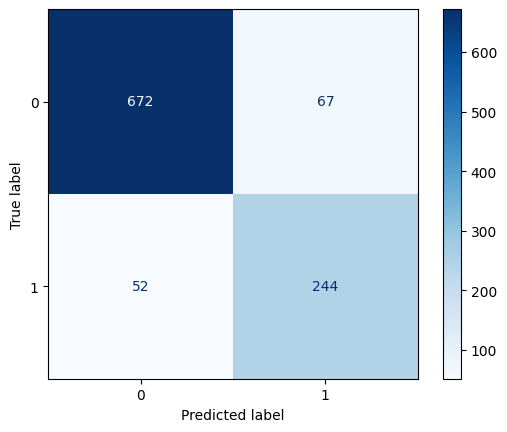

In [38]:
from sklearn.metrics import (
    ConfusionMatrixDisplay, 
    confusion_matrix, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score )
def report(classifier, X_test, y_test):
    y_pred = classifier.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    # Confusion matrix display
    disp = ConfusionMatrixDisplay(cm, display_labels=classifier.classes_)
    disp.plot(cmap="Blues")
    
    # Print metrics
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
    
   

# ---- Call the report function ----
report(knn, X_test, y_test)


## Support Vector Machine

In [47]:
from sklearn.svm import SVC

model = SVC(kernel='linear',gamma='auto',random_state=10)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred

array([0, 0, 1, ..., 0, 1, 0], dtype=int64)

Accuracy:  0.9594
Precision: 0.9205
Recall:    0.9392
F1 Score:  0.9298


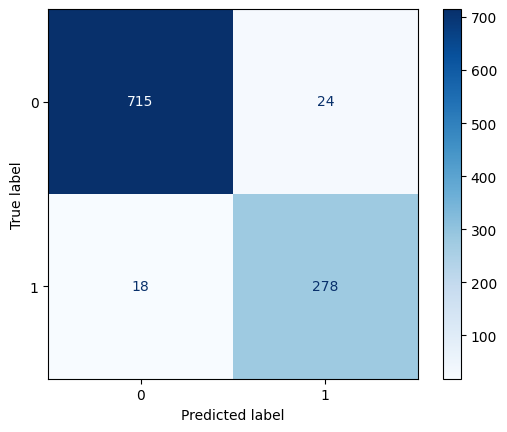

In [48]:
report(model, X_test, y_test)